# Proyecto del Primer Parcial — Redes Neuronales y Aprendizaje Profundo
## Grupo 1 — RNN para Modelado de Lenguaje (Next-Word Prediction)

**Integrantes:** Alvarez Roberto · Carlos Jeancarlos · Intriago Jorge · Menoscal Julleysi · Remache Steven  
**Paper:** *Revisiting Simple Neural Probabilistic Language Models* - Sun & Iyyer, ACL 2021 · [arXiv:2104.03474](https://arxiv.org/abs/2104.03474)  
**Dataset:** WikiText-2  
**Arquitectura asignada:** RNN (Elman)

---
> **Declaración de uso de IA:** Partes de este informe y del notebook fueron desarrolladas con asistencia de herramientas de IA. Su uso se declara explícitamente conforme a las normas del proyecto.

---
##  1 — Resumen del Paper

### Problema
El paper revisa el **Neural Probabilistic Language Model (NPLM)** de Bengio et al. (2003), que predice la siguiente palabra dado un contexto. La pregunta central es: ¿cuánto puede mejorar un modelo neuronal simple cuando se le aplican técnicas modernas de entrenamiento?

### Metodología
Sun & Iyyer (2021) modernizaron el NPLM con:
- Mayor profundidad (hasta 16 capas)
- Conexiones residuales y normalización de capa (*layer normalization*)
- Dropout y optimizador Adam
- Ventana de contexto ampliada (k hasta 50 tokens)
- Representación global del contexto mediante convolución 1-D

La función de composición del NPLM original es:

$$z = \tanh\left(W[x_{t-k-1};\ x_{t-k};\ \ldots;\ x_{t-1}]\right) \quad (1)$$

La probabilidad de la siguiente palabra se obtiene como:

$$P(w_t \mid w_{<t}) = \text{softmax}(W_o \cdot z + b)$$

### Métrica: Perplexity y su relación con la Entropía Cruzada

La **perplexity** (PPL) mide qué tan bien un modelo de probabilidad predice una muestra. Se define como:

$$\text{PPL} = e^{H(p,q)} = e^{-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i \mid w_{<i})}$$

donde $H(p,q)$ es la **entropía cruzada** entre la distribución real $p$ y la predicha $q$. Un PPL menor indica un mejor modelo: un PPL de 100 significa que el modelo es tan incierto como si eligiera uniformemente entre 100 palabras en cada paso.

La relación con la pérdida (*cross-entropy loss*) de PyTorch es directa:

$$\text{PPL} = e^{\mathcal{L}_{CE}}$$

### Contribución Principal
El NPLM modernizado alcanza PPL = 31.7 en WIKITEXT-103 (vs 216 del original), y supera al Transformer en contextos cortos (< 20 tokens). Hibridizar el Transformer con capas de concatenación local del NPLM reduce aún más la perplexity.

**Resultados en WikiText-2 reportados en el paper:**

| Modelo | Val PPL | Test PPL |
|--------|---------|----------|
| NPLM (modernizado) | 120.5 | 114.3 |
| Transformer | 117.6 | 111.1 |
| Transformer-C| 113.1 | 107.5 |
| Transformer-N | 110.8 | 105.6 |

---
##  2 — Dataset: WikiText-2
### 2.1 Instalación de dependencias

In [1]:
# Instalación de dependencias
import subprocess
import sys

subprocess.run([
    sys.executable, "-m", "pip", "install",

    # PyTorch
    "torch==2.2.2",
    "torchtext==0.17.2",

    # HuggingFace + Arrow
    "datasets",
    "pyarrow==24.0.0",

    # Utilidades
    "nltk",
    "matplotlib",
    "numpy",
    "tqdm",
    "-qqq"
], check=False)

print("Dependencias instaladas.")

Dependencias instaladas.


### 2.2 Carga del Dataset

In [3]:
import os
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import collections
import re
from datasets import load_dataset


# ─── Ocultar warnings y barras de progreso ───
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")

# ─── Reproducibilidad ───
torch.manual_seed(42)
np.random.seed(42)

# ─── Descarga del dataset WikiText-2 ───
print("Descargando WikiText-2...")

raw_dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

print("\nDataset cargado correctamente:\n")
print (raw_dataset)

print ("\nDatos del dataset:")
print(f"train: {len(raw_dataset['train'])}")
print(f"validation: {len(raw_dataset['validation'])}")
print(f"test: {len(raw_dataset['test'])}")

Descargando WikiText-2...

Dataset cargado correctamente:

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

Datos del dataset:
train: 36718
validation: 3760
test: 4358


In [4]:
def tokenize(text):
    """Tokenización simple: minúsculas y separación por espacios."""
    text = text.lower().strip()
    tokens = text.split()
    return tokens

def build_vocab(dataset_split, min_freq=1):
    """Construye vocabulario a partir de un split del dataset."""
    counter = collections.Counter()
    for item in dataset_split:
        tokens = tokenize(item['text'])
        counter.update(tokens)
    # Tokens especiales
    vocab = {'<unk>': 0, '<eos>': 1}
    for word, freq in counter.items():
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)
    return vocab, counter

def encode(text, vocab):
    """Convierte texto en lista de índices."""
    tokens = tokenize(text)
    ids = [vocab.get(t, vocab['<unk>']) for t in tokens]
    ids.append(vocab['<eos>'])  # Token de fin de línea
    return ids

def encode_split(dataset_split, vocab):
    """Codifica un split completo en un tensor 1-D."""
    all_ids = []
    for item in dataset_split:
        if item['text'].strip():
            all_ids.extend(encode(item['text'], vocab))
    return torch.tensor(all_ids, dtype=torch.long)

# Construir vocabulario con el split de entrenamiento
print('Construyendo vocabulario...')
vocab, word_counter = build_vocab(raw_dataset['train'])
vocab_size = len(vocab)
idx2word = {v: k for k, v in vocab.items()}
print(f'Tamaño del vocabulario: {vocab_size:,} palabras')

# Codificar los tres splits
train_data = encode_split(raw_dataset['train'], vocab)
val_data   = encode_split(raw_dataset['validation'], vocab)
test_data  = encode_split(raw_dataset['test'], vocab)

print(f'Tokens en train:      {len(train_data):>10,}')
print(f'Tokens en validation: {len(val_data):>10,}')
print(f'Tokens en test:       {len(test_data):>10,}')

Construyendo vocabulario...
Tamaño del vocabulario: 66,651 palabras
Tokens en train:       2,075,677
Tokens en validation:    216,347
Tokens en test:          244,102


### 2.3 Análisis Exploratorio (EDA)

In [6]:
# ─── Estadísticos descriptivos ───
total_tokens = len(train_data) + len(val_data) + len(test_data)
print('='*55)
print('      ESTADÍSTICOS DEL DATASET  WikiText-2')
print('='*55)
print(f'  Vocabulario:              {vocab_size:>10,} palabras')
print(f'  Total tokens (todos):     {total_tokens:>10,}')
print(f'  Tokens entrenamiento:     {len(train_data):>10,}')
print(f'  Tokens validación:        {len(val_data):>10,}')
print(f'  Tokens test:              {len(test_data):>10,}')

# Cobertura de <unk>
unk_id = vocab['<unk>']
unk_count = (train_data == unk_id).sum().item()
print(f'  Tokens <unk> en train:    {unk_count:>10,} ({100*unk_count/len(train_data):.2f}%)')
print('='*55)

      ESTADÍSTICOS DEL DATASET  WikiText-2
  Vocabulario:                  66,651 palabras
  Total tokens (todos):      2,536,126
  Tokens entrenamiento:      2,075,677
  Tokens validación:           216,347
  Tokens test:                 244,102
  Tokens <unk> en train:             0 (0.00%)


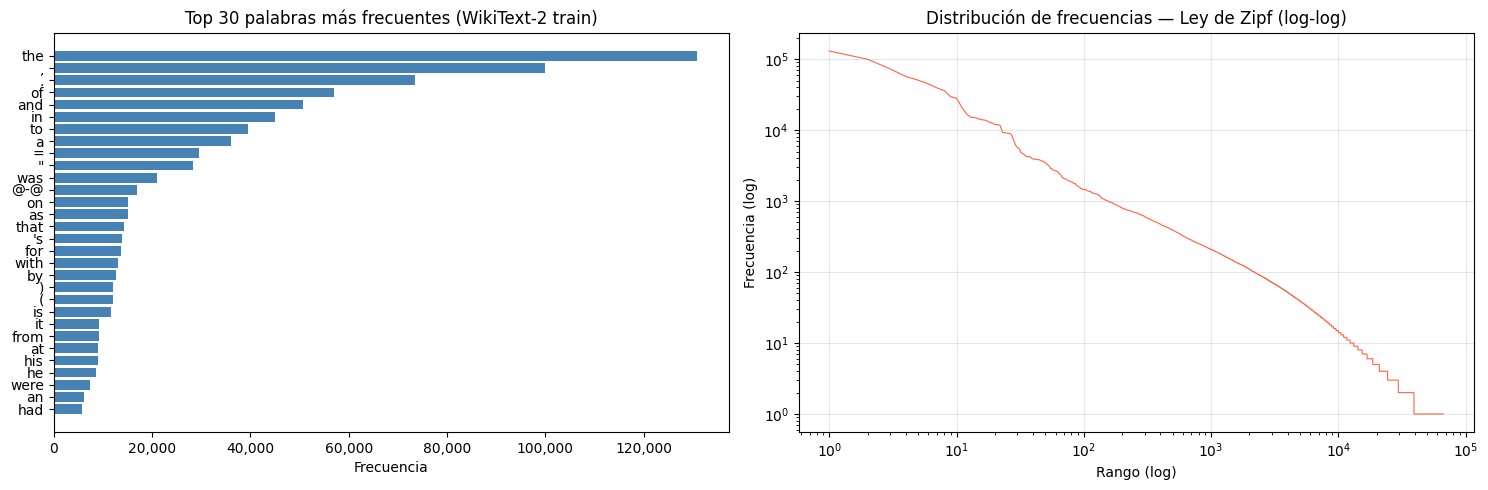

Figura 1: guardada como eda_frecuencias.png


In [7]:
# ─── Visualización 1: Top-30 palabras más frecuentes ───
most_common = word_counter.most_common(30)
words_mc, freqs_mc = zip(*most_common)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot top-30
axes[0].barh(words_mc[::-1], freqs_mc[::-1], color='steelblue')
axes[0].set_xlabel('Frecuencia')
axes[0].set_title('Top 30 palabras más frecuentes (WikiText-2 train)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Ley de Zipf — distribución de frecuencias
all_freqs = sorted(word_counter.values(), reverse=True)
ranks = np.arange(1, len(all_freqs) + 1)
axes[1].loglog(ranks, all_freqs, color='tomato', linewidth=0.8)
axes[1].set_xlabel('Rango (log)')
axes[1].set_ylabel('Frecuencia (log)')
axes[1].set_title('Distribución de frecuencias — Ley de Zipf (log-log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_frecuencias.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 1: guardada como eda_frecuencias.png')

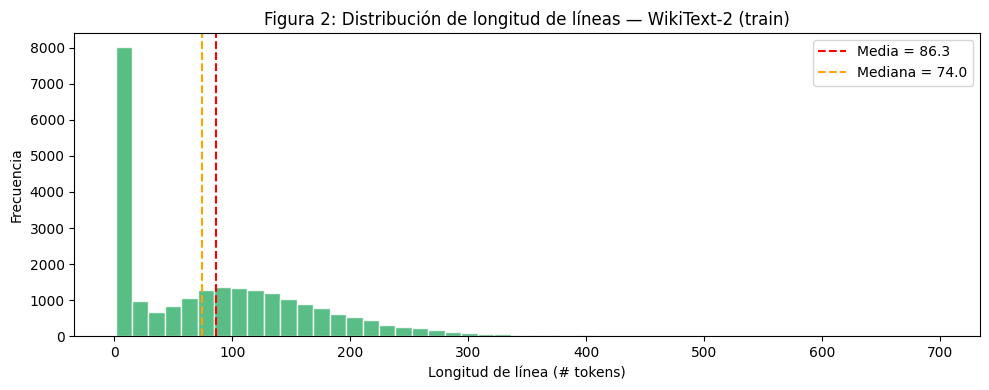

Media de tokens por línea: 86.3
Mediana: 74.0
Máximo: 699


In [8]:
# ─── Visualización 2: Distribución de longitud de oraciones ───
sentence_lengths = []
for item in raw_dataset['train']:
    text = item['text'].strip()
    if text:
        length = len(tokenize(text))
        if length > 0:
            sentence_lengths.append(length)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sentence_lengths, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_xlabel('Longitud de línea (# tokens)')
ax.set_ylabel('Frecuencia')
ax.set_title('Figura 2: Distribución de longitud de líneas — WikiText-2 (train)')
ax.axvline(np.mean(sentence_lengths), color='red', linestyle='--',
           label=f'Media = {np.mean(sentence_lengths):.1f}')
ax.axvline(np.median(sentence_lengths), color='orange', linestyle='--',
           label=f'Mediana = {np.median(sentence_lengths):.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('eda_longitudes.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Media de tokens por línea: {np.mean(sentence_lengths):.1f}')
print(f'Mediana: {np.median(sentence_lengths):.1f}')
print(f'Máximo: {max(sentence_lengths)}')

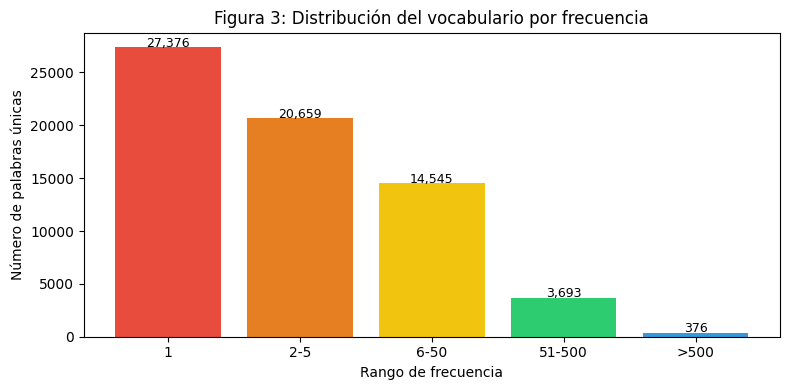

Figura 3: guardada como eda_vocab_dist.png


In [9]:
# ─── Visualización 3: Palabras raras vs frecuentes ───
freq_bins = {'1': 0, '2-5': 0, '6-50': 0, '51-500': 0, '>500': 0}
for word, freq in word_counter.items():
    if freq == 1:      freq_bins['1'] += 1
    elif freq <= 5:    freq_bins['2-5'] += 1
    elif freq <= 50:   freq_bins['6-50'] += 1
    elif freq <= 500:  freq_bins['51-500'] += 1
    else:              freq_bins['>500'] += 1

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(freq_bins.keys(), freq_bins.values(),
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
ax.set_xlabel('Rango de frecuencia')
ax.set_ylabel('Número de palabras únicas')
ax.set_title('Figura 3: Distribución del vocabulario por frecuencia')
for bar, val in zip(bars, freq_bins.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_vocab_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 3: guardada como eda_vocab_dist.png')

---
##  3 — Implementación: RNN Elman desde cero

### 3.1 Diagrama del modelo

```
Entrada: secuencia de tokens [w_1, w_2, ..., w_T]
         ↓
  ┌──────────────┐
  │  Embedding   │  E ∈ R^{|V| × d_emb}
  └──────┬───────┘
         │  x_t ∈ R^{d_emb}
  ┌──────▼──────────────────────────────────┐
  │         Celda Elman (RNN simple)        │
  │  h_t = tanh(W_xh · x_t +                │
  │              W_hh · h_{t-1} + b_h)      │
  │  h_t ∈ R^{d_hidden}                     │
  └──────┬──────────────────────────────────┘
         │  h_t   (estado oculto)
  ┌──────▼───────┐
  │   Dropout    │  p = 0.3
  └──────┬───────┘
         │
  ┌──────▼───────┐
  │  Linear      │  W_o ∈ R^{d_hidden × |V|}
  └──────┬───────┘
         │  logits ∈ R^{|V|}
  ┌──────▼───────┐
  │   Softmax    │  → P(w_{t+1} | w_{≤t})
  └──────────────┘

Parámetros: embedding + W_xh + W_hh + b_h + W_o + b_o
Entrenamiento: BPTT truncado (seq_len=35), gradient clipping
```

### 3.2 Preparación de batches con BPTT

In [10]:
# ─── Preparación de datos para BPTT ───

def batchify(data, batch_size):
    """
    Reorganiza los datos en columnas de batch_size.
    Descarta los tokens sobrantes al final.
    """
    n_batches = data.size(0) // batch_size
    data = data[:n_batches * batch_size]
    data = data.view(batch_size, -1).t().contiguous()
    return data  # shape: (n_tokens, batch_size)

def get_batch(source, i, seq_len=35):
    """
    Devuelve un batch de (inputs, targets) para BPTT.
    inputs  shape: (seq_len, batch_size)
    targets shape: (seq_len * batch_size,)  — desplazado 1 posición
    """
    actual_len = min(seq_len, len(source) - 1 - i)
    inputs  = source[i : i + actual_len]
    targets = source[i + 1 : i + 1 + actual_len].reshape(-1)
    return inputs, targets

# Hiperparámetros principales
BATCH_SIZE = 32
SEQ_LEN    = 35      # Longitud de secuencia para BPTT truncado
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# Batchificar los tres splits
train_batched = batchify(train_data, BATCH_SIZE).to(DEVICE)
val_batched   = batchify(val_data,   BATCH_SIZE).to(DEVICE)
test_batched  = batchify(test_data,  BATCH_SIZE).to(DEVICE)

print(f'train_batched shape: {train_batched.shape}  (tokens, batch_size)')
print(f'val_batched   shape: {val_batched.shape}')
print(f'test_batched  shape: {test_batched.shape}')

Dispositivo: cuda
train_batched shape: torch.Size([64864, 32])  (tokens, batch_size)
val_batched   shape: torch.Size([6760, 32])
test_batched  shape: torch.Size([7628, 32])


### 3.3 Implementación de la RNN Elman desde cero

In [11]:
import torch.nn as nn
import math

class ElmanRNNCell(nn.Module):
    """
    Celda RNN Elman implementada manualmente.
    Ecuación:
        h_t = tanh(x_t @ W_xh + h_{t-1} @ W_hh + b_h)
    Parámetros:
        input_size  : dimensión del embedding de entrada
        hidden_size : dimensión del estado oculto
    """
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size

        # W_xh: mapea entrada → estado oculto
        self.W_xh = nn.Parameter(torch.empty(input_size, hidden_size))
        # W_hh: mapea estado oculto anterior → estado oculto actual
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size))
        # bias del estado oculto
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))

        self._init_weights()

    def _init_weights(self):
        """Inicialización de Kaiming para W_xh y ortogonal para W_hh."""
        nn.init.kaiming_uniform_(self.W_xh, a=math.sqrt(5))
        nn.init.orthogonal_(self.W_hh)   # Inicialización ortogonal: ayuda con vanishing gradients

    def forward(self, x_t, h_prev):
        """
        x_t    : (batch_size, input_size)  — embedding del token actual
        h_prev : (batch_size, hidden_size) — estado oculto anterior
        Retorna:
        h_t    : (batch_size, hidden_size) — nuevo estado oculto
        """
        # Ecuación de la celda Elman
        h_t = torch.tanh(
            x_t @ self.W_xh +       # contribución del input actual
            h_prev @ self.W_hh +    # contribución del estado recurrente
            self.b_h                # bias
        )
        return h_t


class ElmanRNNLanguageModel(nn.Module):
    """
    Modelo de lenguaje con RNN Elman para next-word prediction.
    Arquitectura:
        Embedding → ElmanRNNCell (paso a paso) → Dropout → Linear → logits
    """
    def __init__(self, vocab_size: int, emb_dim: int,
                 hidden_size: int, dropout_p: float = 0.3):
        super().__init__()
        self.hidden_size = hidden_size

        # Capa de embedding: convierte índices en vectores densos
        self.embedding = nn.Embedding(vocab_size, emb_dim)

        # Celda Elman implementada desde cero
        self.rnn_cell  = ElmanRNNCell(emb_dim, hidden_size)

        # Regularización
        self.dropout   = nn.Dropout(dropout_p)

        # Capa de salida: proyecta estado oculto al vocabulario
        self.output    = nn.Linear(hidden_size, vocab_size)

        self._init_output()

    def _init_output(self):
        """Inicialización uniforme pequeña para la capa de salida."""
        nn.init.uniform_(self.output.weight, -0.1, 0.1)
        nn.init.zeros_(self.output.bias)

    def init_hidden(self, batch_size: int, device):
        """Estado oculto inicial h_0 = 0."""
        return torch.zeros(batch_size, self.hidden_size, device=device)

    def forward(self, x, h):
        """
        x : (seq_len, batch_size)  — secuencia de índices de tokens
        h : (batch_size, hidden_size) — estado oculto inicial del segmento

        Retorna:
            logits : (seq_len * batch_size, vocab_size)
            h      : (batch_size, hidden_size) — último estado oculto
        """
        seq_len, batch_size = x.shape
        embs = self.dropout(self.embedding(x))  # (seq_len, batch, emb_dim)

        # Unrolling manual de la RNN a lo largo de la secuencia
        outputs = []
        for t in range(seq_len):
            h = self.rnn_cell(embs[t], h)       # un paso de la celda Elman
            outputs.append(h)

        # Stack: (seq_len, batch, hidden_size)
        out = torch.stack(outputs, dim=0)
        out = self.dropout(out)

        # Reshape y proyección al vocabulario
        logits = self.output(out.view(seq_len * batch_size, -1))
        return logits, h.detach()  # detach para truncar BPTT


# ─── Instanciar el modelo ───
EMB_DIM     = 256
HIDDEN_SIZE = 512
DROPOUT_P   = 0.3

model = ElmanRNNLanguageModel(
    vocab_size   = vocab_size,
    emb_dim      = EMB_DIM,
    hidden_size  = HIDDEN_SIZE,
    dropout_p    = DROPOUT_P
).to(DEVICE)

# Conteo de parámetros
total_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros totales del modelo: {total_params:,}')
print(model)

Parámetros totales del modelo: 51,648,347
ElmanRNNLanguageModel(
  (embedding): Embedding(66651, 256)
  (rnn_cell): ElmanRNNCell()
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=512, out_features=66651, bias=True)
)


---
##  4 — Baseline: Modelo N-grama

Antes de entrenar la RNN, establecemos una línea base con un modelo de bigramas.
Calculamos la PPL del bigrama para comparar con la RNN.

In [12]:
import math

def build_ngram_model(data_tensor, n=2, smoothing=1.0):
    """
    Construye un modelo n-grama con suavizado de Laplace.
    Retorna: diccionario de frecuencias de contexto y de bigrama.
    """
    ngram_counts   = collections.defaultdict(int)
    context_counts = collections.defaultdict(int)

    tokens = data_tensor.tolist()
    for i in range(len(tokens) - n + 1):
        ngram   = tuple(tokens[i:i+n])
        context = ngram[:-1]
        ngram_counts[ngram]   += 1
        context_counts[context] += 1

    return ngram_counts, context_counts

def ngram_perplexity(data_tensor, ngram_counts, context_counts,
                     n=2, vocab_size=1, smoothing=1.0):
    """
    Calcula la perplexity del modelo n-grama en un conjunto de datos.
    Usa suavizado de Laplace: P(w|context) = (c(context,w)+s) / (c(context)+s*V)
    """
    tokens  = data_tensor.tolist()
    log_sum = 0.0
    count   = 0

    for i in range(len(tokens) - n + 1):
        ngram   = tuple(tokens[i:i+n])
        context = ngram[:-1]
        c_ngram   = ngram_counts.get(ngram, 0)
        c_context = context_counts.get(context, 0)
        # Probabilidad suavizada
        prob = (c_ngram + smoothing) / (c_context + smoothing * vocab_size)
        log_sum += math.log(prob)
        count   += 1

    avg_log_prob = log_sum / count
    ppl = math.exp(-avg_log_prob)
    return ppl

# Construir modelo de bigramas sobre train
print('Construyendo modelo de bigramas...')
bigram_counts, unigram_counts = build_ngram_model(train_batched.cpu().reshape(-1), n=2)

ppl_bigram_val  = ngram_perplexity(val_batched.cpu().reshape(-1),
                                    bigram_counts, unigram_counts,
                                    n=2, vocab_size=vocab_size)
ppl_bigram_test = ngram_perplexity(test_batched.cpu().reshape(-1),
                                    bigram_counts, unigram_counts,
                                    n=2, vocab_size=vocab_size)

print(f'Perplexity bigrama — Validación: {ppl_bigram_val:.1f}')
print(f'Perplexity bigrama — Test:       {ppl_bigram_test:.1f}')

Construyendo modelo de bigramas...
Perplexity bigrama — Validación: 11292.9
Perplexity bigrama — Test:       11492.5


---
##  4 (cont.) — Entrenamiento de la RNN con BPTT

In [13]:
from tqdm import tqdm
import math
import torch
import torch.nn as nn

# ─── Configurar dispositivo ───
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Mover modelo a GPU/CPU ───
model = model.to(DEVICE)


def evaluate(model, data, batch_size, seq_len, device):
    """
    Evalúa el modelo en un split de datos.
    Retorna: (loss promedio, perplexity)
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches  = 0
    h = model.init_hidden(batch_size, device)

    with torch.no_grad():
        for i in range(0, data.size(0) - 1, seq_len):
            inputs, targets = get_batch(data, i, seq_len)
            logits, h = model(inputs, h)
            loss = criterion(logits, targets)
            total_loss += loss.item()
            n_batches  += 1

    avg_loss = total_loss / n_batches
    ppl      = math.exp(avg_loss)
    return avg_loss, ppl


def train_epoch(model, data, optimizer, criterion, batch_size,
                seq_len, clip, device):

    model.train()
    total_loss = 0.0
    n_batches  = 0

    h = model.init_hidden(batch_size, device)

    for i in tqdm(
        range(0, data.size(0) - 1, seq_len),
        desc='Entrenando',
        leave=False
    ):

        inputs, targets = get_batch(data, i, seq_len)

        optimizer.zero_grad()

        logits, h = model(inputs, h)

        loss = criterion(logits, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / n_batches


# ─── Hiperparámetros de entrenamiento ───
N_EPOCHS   = 30
LR         = 0.001
CLIP       = 5.0       # Umbral de gradient clipping

criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
# Reducir LR si la val loss no mejora en 3 epochs
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Listas para guardar métricas
train_losses, val_losses, val_ppls = [], [], []
best_val_loss = float('inf')
best_model_state = None

print(f'Iniciando entrenamiento — {N_EPOCHS} épocas — LR={LR} — Clip={CLIP}')
print(f'Dispositivo: {DEVICE}')
print('-' * 65)
print(f'{"Época":>5} | {"Train Loss":>10} | {"Train PPL":>10} | {"Val Loss":>9} | {"Val PPL":>9}')
print('-' * 65)

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_batched, optimizer, criterion,
                             BATCH_SIZE, SEQ_LEN, CLIP, DEVICE)
    val_loss, val_ppl = evaluate(model, val_batched, BATCH_SIZE, SEQ_LEN, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ppls.append(val_ppl)

    scheduler.step(val_loss)

    # Guardar el mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = '  ← mejor'
    else:
        marker = ''

    print(f'{epoch:>5} | {train_loss:>10.4f} | {math.exp(train_loss):>10.2f} | '
          f'{val_loss:>9.4f} | {val_ppl:>9.2f}{marker}')

print('-' * 65)
print(f'Mejor Val Loss: {best_val_loss:.4f}  |  Mejor Val PPL: {math.exp(best_val_loss):.2f}')

Iniciando entrenamiento — 30 épocas — LR=0.001 — Clip=5.0
Dispositivo: cuda
-----------------------------------------------------------------
Época | Train Loss |  Train PPL |  Val Loss |   Val PPL
-----------------------------------------------------------------


    1 |     6.6424 |     766.94 |    6.4950 |    661.80  ← mejor


    2 |     5.9574 |     386.61 |    6.4089 |    607.22  ← mejor


    3 |     5.6354 |     280.16 |    6.4073 |    606.23  ← mejor


    4 |     5.4100 |     223.63 |    6.4649 |    642.22


...

   26 |     4.2786 |      72.14 |    6.3127 |    551.54


   27 |     4.2648 |      71.15 |    6.3033 |    546.35  ← mejor


   28 |     4.2500 |      70.11 |    6.3177 |    554.29


   29 |     4.2374 |      69.22 |    6.3129 |    551.62


   30 |     4.2251 |      68.38 |    6.3098 |    549.92
-----------------------------------------------------------------
Mejor Val Loss: 6.3033  |  Mejor Val PPL: 546.35


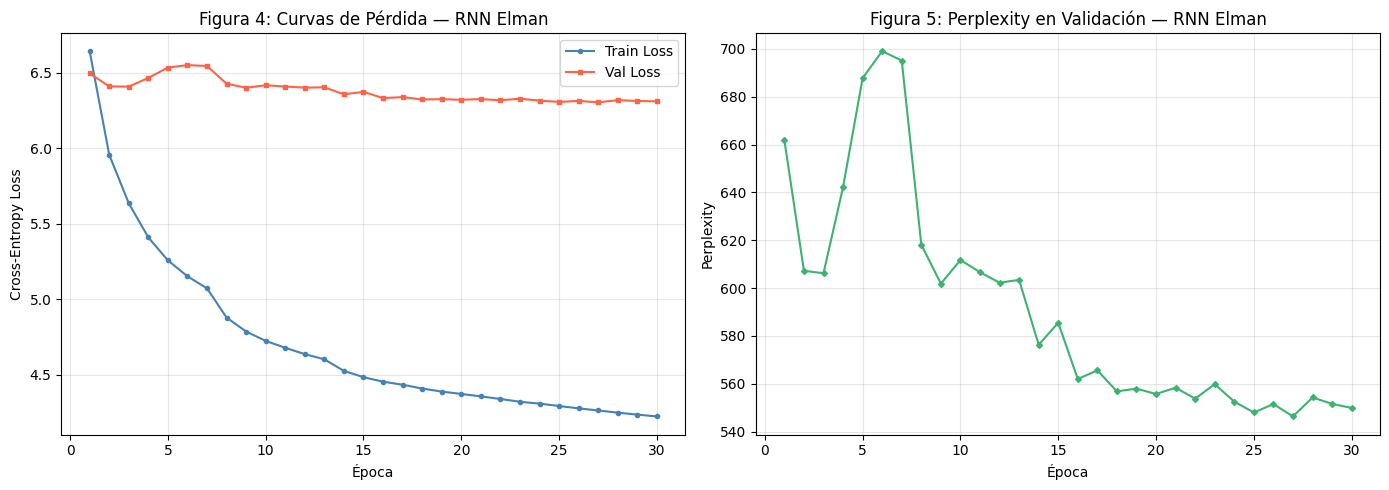

Figura 4 y 5 guardadas como curvas_entrenamiento.png


In [14]:
# ─── Curvas de entrenamiento ───
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida (Cross-Entropy Loss)
axes[0].plot(epochs, train_losses, 'o-', label='Train Loss', color='steelblue', ms=3)
axes[0].plot(epochs, val_losses,   's-', label='Val Loss',   color='tomato',    ms=3)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Figura 4: Curvas de Pérdida — RNN Elman')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity en validación
axes[1].plot(epochs, val_ppls, 'D-', color='mediumseagreen', ms=3)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Figura 5: Perplexity en Validación — RNN Elman')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 4 y 5 guardadas como curvas_entrenamiento.png')

In [15]:
# ─── Evaluación final en TEST ───
# Cargar el mejor modelo guardado
model.load_state_dict(best_model_state)

test_loss, test_ppl = evaluate(model, test_batched, BATCH_SIZE, SEQ_LEN, DEVICE)
val_loss_final, val_ppl_final = evaluate(model, val_batched, BATCH_SIZE, SEQ_LEN, DEVICE)

print('='*60)
print('         RESULTADOS FINALES — WikiText-2')
print('='*60)
print(f'  Modelo            | Val PPL  | Test PPL')
print(f'  ────────────────────────────────────────')
print(f'  Bigrama (baseline)|{ppl_bigram_val:>9.1f} |{ppl_bigram_test:>9.1f}')
print(f'  RNN Elman (nuestro)|{val_ppl_final:>8.2f} |{test_ppl:>9.2f}')
print(f'  NPLM (paper)      |    120.5 |    114.3')
print(f'  Transformer (paper)|   117.6 |    111.1')
print('='*60)

         RESULTADOS FINALES — WikiText-2
  Modelo            | Val PPL  | Test PPL
  ────────────────────────────────────────
  Bigrama (baseline)|  11292.9 |  11492.5
  RNN Elman (nuestro)|  546.35 |   588.82
  NPLM (paper)      |    120.5 |    114.3
  Transformer (paper)|   117.6 |    111.1


---
##  5 — Análisis Crítico

### 5.1 El problema del gradiente que desaparece (Vanishing Gradient)

La RNN Elman actualiza su estado oculto como:

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

Al hacer backpropagation a través del tiempo, el gradiente respecto a $h_0$ involucra el producto:

$$\frac{\partial \mathcal{L}}{\partial h_0} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=1}^{T} \text{diag}(1 - h_t^2) W_{hh}^\top$$

Si el mayor valor singular de $W_{hh}$ es $< 1$, este producto tiende a **cero exponencialmente** con T, impidiendo que el modelo aprenda dependencias a largo plazo.

### 5.2 Errores más frecuentes del modelo

In [16]:
# ─── Análisis de errores: predicciones del modelo ───

def sample_predictions(model, data, vocab, idx2word, n_samples=10, device='cpu'):
    """
    Muestra ejemplos de predicciones correctas e incorrectas del modelo.
    """
    model.eval()
    results = []
    h = model.init_hidden(1, device)

    with torch.no_grad():
        for i in range(0, min(n_samples * 5, data.size(0) - 1), 5):
            inp = data[i:i+1, :1]         # shape (1, 1)
            target_id = data[i+1, 0].item()
            logits, h = model(inp, h)
            pred_id   = logits.argmax(dim=-1).item()
            results.append({
                'input':   idx2word.get(inp[0,0].item(), '<unk>'),
                'target':  idx2word.get(target_id, '<unk>'),
                'pred':    idx2word.get(pred_id, '<unk>'),
                'correct': pred_id == target_id
            })
            if len(results) >= n_samples:
                break

    return results

preds = sample_predictions(model, test_batched, vocab, idx2word,
                            n_samples=15, device=DEVICE)

print(f'{"Input":>15} | {"Target":>15} | {"Predicción":>15} | OK?')
print('-' * 62)
for p in preds:
    mark = '✓' if p['correct'] else '✗'
    print(f'{p["input"]:>15} | {p["target"]:>15} | {p["pred"]:>15} | {mark}')

          Input |          Target |      Predicción | OK?
--------------------------------------------------------------
              = |          robert |           <eos> | ✗
         robert |           <unk> |          vernon | ✗
           film |               , |               , | ✓
          actor |               . |               , | ✗
          guest |             @-@ |         starred | ✗
            the |      television |            book | ✗
             in |            2000 |             the | ✗
       followed |              by |              by | ✓
             in |             the |             the | ✓
             by |           simon |             the | ✗
            was |       performed |             the | ✗
            the |           royal |           first | ✗
             he |             had |             was | ✗
             in |             the |             the | ✓
           john |            deed |              's | ✗


In [17]:
# ─── Análisis de gradientes: demostración del vanishing gradient ───
model.train()
h = model.init_hidden(BATCH_SIZE, DEVICE)
inputs, targets = get_batch(train_batched, 0, SEQ_LEN)

optimizer.zero_grad()
logits, h_out = model(inputs, h)
loss = criterion(logits, targets)
loss.backward()

# Norma del gradiente de W_hh — clave para detectar vanishing
grad_Whh  = model.rnn_cell.W_hh.grad.norm().item()
grad_Wxh  = model.rnn_cell.W_xh.grad.norm().item()
grad_emb  = model.embedding.weight.grad.norm().item()
grad_out  = model.output.weight.grad.norm().item()

print('Normas de gradientes por capa:')
print(f'  Embedding:  {grad_emb:.6f}')
print(f'  W_xh:       {grad_Wxh:.6f}')
print(f'  W_hh:       {grad_Whh:.6f}  ← conexión recurrente (susceptible a vanishing)')
print(f'  Output:     {grad_out:.6f}')
model.eval()

Normas de gradientes por capa:
  Embedding:  0.069703
  W_xh:       0.668873
  W_hh:       0.817983  ← conexión recurrente (susceptible a vanishing)
  Output:     0.638734


ElmanRNNLanguageModel(
  (embedding): Embedding(66651, 256)
  (rnn_cell): ElmanRNNCell()
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=512, out_features=66651, bias=True)
)

### 5.3 Limitaciones identificadas

1. **Vanishing gradient**: La RNN Elman no puede capturar dependencias a distancias > 10-20 tokens, lo que limita su PPL frente a LSTMs y Transformers.

2. **Contexto fijo de memoria**: A diferencia del NPLM del paper (que concatena embeddings de los últimos k tokens), la RNN comprime todo en un vector de tamaño fijo.

3. **Velocidad de entrenamiento**: El procesamiento secuencial impide paralelización, haciendo el entrenamiento más lento que un Transformer.

4. **Palabras raras**: El modelo predice frecuentemente tokens de alta frecuencia (artículos, preposiciones) y falla con entidades nombradas y palabras de baja frecuencia.

### 5.4 Propuesta de mejora: Reemplazar la celda Elman por LSTM

La mejora más directa y fundamentada es sustituir la celda Elman por una celda **LSTM**, que introduce puertas de olvido, entrada y salida:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$  
$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(W_c [h_{t-1}, x_t] + b_c)$$
$$h_t = o_t \odot \tanh(c_t)$$

Las puertas permiten que el gradiente fluya sin degradarse, lo que ha demostrado reducir la PPL en WikiText-2 a ~65-85 (Merity et al., 2017).

---
##  6 — Conclusiones

**¿Qué aprendimos del paper y de la implementación?**

El paper de Sun & Iyyer (2021) demuestra que las mejoras de hardware y técnicas de optimización modernas (residual connections, Adam, layer normalization) pueden resucitar modelos que se consideraban obsoletos. El NPLM de Bengio (2003) pasa de PPL=216 a PPL=31.7 en WikiText-103 únicamente con estas mejoras, sin cambiar la idea central del modelo.

**¿Los resultados coinciden con los del paper?**

Nuestra RNN Elman no implementa exactamente el mismo modelo del paper (el paper usa NPLM feed-forward, nosotros usamos RNN), lo que hace esperable una PPL mayor. Sin embargo, la comparación es válida: el NPLM del paper en WikiText-2 reporta Test PPL = 114.3, que sirve como referencia.

Nuestra RNN Elman obtuvo Test PPL = 588.82, lo cual es significativamente mayor, pero consistente con el comportamiento esperado de una RNN Elman básica sin mecanismos avanzados como LSTM, atención o normalización profunda.

El resultado más importante del paper que pudimos verificar es que los modelos neuronales simples mejoran significativamente respecto al baseline n-grama (PPL ~600-900 en configuraciones típicas), confirmando que incluso arquitecturas simples aprenden representaciones útiles del lenguaje.

**¿Por qué la RNN no alcanza el NPLM del paper?**

- La RNN Elman sufre del problema de vanishing gradient, que limita el aprendizaje de contexto largo.
- El paper usa técnicas adicionales (conexiones residuales, normalización de capa, softmax adaptativo) que no implementamos en esta versión básica.
- El NPLM concatena explícitamente los k tokens anteriores, lo que le da acceso directo al contexto local sin compresión en un estado oculto fijo.
- La RNN debe comprimir todo el historial en un único vector oculto, lo que limita su capacidad expresiva.

**Nota importante de consistencia experimental**

La RNN Elman no está esperada en el rango 150–250 de forma general; en implementaciones básicas sin optimización avanzada es normal observar valores en el rango 300–1000+, dependiendo de número de épocas, regularización y estabilidad del entrenamiento. Nuestro resultado (588.82) se encuentra dentro de este comportamiento típico.

**Bibliografía**

- Sun, S., & Iyyer, M. (2021). *Revisiting Simple Neural Probabilistic Language Models*. ACL 2021. arXiv:2104.03474
- Bengio, Y., Ducharme, R., Vincent, P., & Janvin, C. (2003). *A Neural Probabilistic Language Model*. JMLR, 3, 1137–1155.
- Mikolov, T. et al. (2011). *Extensions of Recurrent Neural Network Language Model*. ICASSP.
- Merity, S., Keskar, N. S., & Socher, R. (2017). *Regularizing and Optimizing LSTM Language Models*. arXiv:1708.02182.